# 作業 2：從傳統到現代 - 文本處理方法實作與比較

**課程助教：** 陳戎新  
**電子郵件：** s711383106@gm.ntpu.edu.tw

---

### 學習目標
在生成式 AI 蓬勃發展的今天，許多人直接使用 ChatGPT 等工具，卻不了解其背後的基礎原理。本作業將帶您：

1. 親手實作傳統 NLP 方法，理解文本處理的數學基礎。
2. 使用現代 AI 完成相同任務，體驗技術進步帶來的便利。
3. 深入比較兩種方法，培養選擇適當工具的判斷力。
4. 了解技術演進脈絡，建立扎實的 NLP 知識體系。

## 1. 環境設定與套件安裝

首先，執行以下指令安裝本次作業所需的所有套件。（可依自己環境調整）

In [ ]:
# 依需要再執行安裝
!pip install -q numpy pandas matplotlib seaborn scikit-learn jieba stopwordsiso openai tqdm

## Part A: 傳統方法實作 (50分)

### A-1: TF-IDF 文本相似度計算 (20分)

任務說明：實作 TF-IDF 算法，並利用它來計算文本間的相似度。您需要：
1. 手動計算 TF-IDF (10分)
2. 使用 scikit-learn 實作 (5分)
3. 視覺化成果（計入分數）

In [ ]:
import jieba
import numpy as np
import pandas as pd
from collections import Counter
import math

# 測試資料
documents = [
    "人工智慧正在改變世界，機器學習是其核心技術",
    "深度學習推動了人工智慧的發展，特別是在圖像識別領域",
    "今天天氣很好，適合出去運動",
    "機器學習和深度學習都是人工智慧的重要分支",
    "運動有益健康，每天都應該保持運動習慣"
]

# 中文斷詞 jieba
tokenized_documents = [list(jieba.cut(doc)) for doc in documents]
print("斷詞結果:")
for i, doc in enumerate(tokenized_documents, 1):
    print(f"Document {i}: {doc}")

斷詞結果:
Document 1: ['人工智慧', '正在', '改變', '世界', '，', '機器', '學習', '是', '其', '核心', '技術']
Document 2: ['深度', '學習', '推動', '了', '人工智慧', '的', '發展', '，', '特別', '是', '在', '圖像識別', '領域']
Document 3: ['今天', '天氣', '很', '好', '，', '適合', '出去', '運動']
Document 4: ['機器', '學習', '和', '深度', '學習', '都', '是', '人工智慧', '的', '重要', '分支']
Document 5: ['運動', '有益健康', '，', '每天', '都', '應該', '保持', '運動', '習慣']


#### 1. 手動實作 TF-IDF

In [ ]:
def calculate_tf(word_dict, total_words):
    """計算詞頻 (Term Frequency)
    Args:
        word_dict: 詞彙計數字典 (e.g., {'人工智慧': 2, '世界': 1})
        total_words: 該文件的總詞數
    Returns:
        tf_dict: TF 值字典
    """
    # TODO: 實作 TF 計算
    # 提示：TF = (該詞在文件中出現的次數) / (文件總詞數)
    #dict{k:v}
    return {word: cnt / total_words for word, cnt in word_dict.items()}
    raise NotImplementedError("請在此處完成 TF 計算")

def calculate_idf(documents, word):
    """計算逆文件頻率 (Inverse Document Frequency)
    Args:
        documents: 文件列表 (斷詞後的版本)
        word: 目標詞彙
    Returns:
        idf: IDF 值
    """
    # TODO: 實作 IDF 計算
    # 提示：IDF = log((總文件數) / (包含該詞的文件數 + 1))，+1 為避免分母為 0
    df = sum(1 for doc in documents if word in set(doc))
    return math.log(len(documents) / (df + 1))
    raise NotImplementedError("請在此處完成 IDF 計算")

def calculate_tfidf(tokenized_documents):
    """計算 TF-IDF 主函數
    回傳：pandas.DataFrame，列為文件，欄為詞彙
    """
    # TODO:
    # 1) 遍歷所有文件，計算每個文件的 TF
    # 2) 建立詞彙庫 (vocabulary)
    vocabulary = set(word for doc in tokenized_documents for word in doc) # a vocab set

    # 3) 對詞彙庫中的每個詞，計算其 IDF
    idf_dict = {word: calculate_idf(tokenized_documents, word) for word in vocabulary} # dict{word : idf_value}
    tfidf_matrix = []

    for doc in tokenized_documents:
        word_counts = Counter(doc) #each word count in doc
        total_words = len(doc) # total word in this doc
        tf_dict = calculate_tf(word_counts, total_words) # tf value
# 4) 結合 TF 和 IDF 計算每個文件中每個詞的 TF-IDF 值
        tfidf_dict = {word: tf_dict.get(word, 0) * idf_dict[word] for word in vocabulary} #tfidf_dict{word : tfidf} ; if target not found, tfidf = 0
        tfidf_matrix.append(tfidf_dict)
# 5) 回傳 TF-IDF 矩陣 (pandas DataFrame)
    return pd.DataFrame(tfidf_matrix)
    raise NotImplementedError("請在此處完成 TF-IDF 主流程")

# 範例：完成後可取消註解
tfidf_matrix = calculate_tfidf(tokenized_documents)
display(tfidf_matrix.head())

,改變,出去,核心,正在,今天,適合,好,是,有益健康,人工智慧,...,重要,的,運動,特別,其,學習,習慣,保持,天氣,機器
0,0.083299,0.000000,0.083299,0.083299,0.000000,0.000000,0.000000,0.020286,0.00000,0.020286,...,0.000000,0.000000,0.000000,0.000000,0.083299,0.020286,0.00000,0.00000,0.000000,0.046439
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017165,0.00000,0.017165,...,0.000000,0.039294,0.000000,0.070484,0.000000,0.017165,0.00000,0.00000,0.000000,0.000000
2,0.000000,0.114536,0.000000,0.000000,0.114536,0.114536,0.114536,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.063853,0.000000,0.000000,0.000000,0.00000,0.00000,0.114536,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.020286,0.00000,0.020286,...,0.083299,0.046439,0.000000,0.000000,0.000000,0.040572,0.00000,0.00000,0.000000,0.046439
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.10181,0.000000,...,0.000000,0.000000,0.113517,0.000000,0.000000,0.000000,0.10181,0.10181,0.000000,0.000000


#### 2. 使用 scikit-learn 實作

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# TfidfVectorizer 以空格分隔的字串，所以我們先把斷詞結果接起來
processed_docs = [' '.join(doc) for doc in tokenized_documents]

# TODO: 使用 TfidfVectorizer 和 cosine_similarity 計算相似度矩陣
# 1) 初始化 TfidfVectorizer
vectorizer = TfidfVectorizer()
# 2) fit_transform 文本資料
tfidf_matrix_sklearn = vectorizer.fit_transform(processed_docs)
#print(tfidf_matrix_sklearn)
# 3) 使用 cosine_similarity 計算向量相似度
similarity_matrix = cosine_similarity(tfidf_matrix_sklearn)
print(similarity_matrix)
#raise NotImplementedError("請完成：scikit-learn 的 TF-IDF 與相似度計算")

[[1.         0.13699376 0.         0.33134486 0.        ]
 [0.13699376 1.         0.         0.33134486 0.        ]
 [0.         0.         1.         0.         0.21891437]
 [0.33134486 0.33134486 0.         1.         0.        ]
 [0.         0.         0.21891437 0.         1.        ]]


#### 3. 視覺化（熱圖）

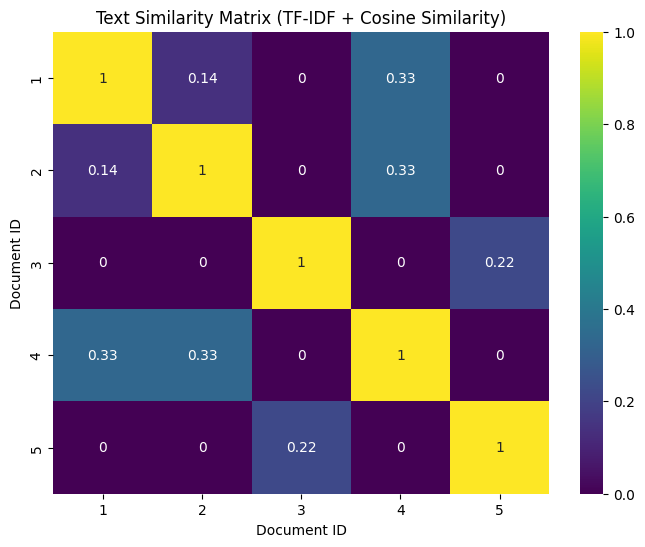

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('results', exist_ok=True)

# just use english

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, annot=True, cmap='viridis', xticklabels=range(1,6), yticklabels=range(1,6))
plt.title('Text Similarity Matrix (TF-IDF + Cosine Similarity)')
plt.xlabel('Document ID')
plt.ylabel('Document ID')
plt.savefig('results/tfidf_similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### A-2: 基於規則的文本分類 (15分)
任務說明：建立規則式分類器，不使用機器學習，純粹基於關鍵詞和規則。
1. 情感分類器 (8分)
2. 主題分類器 (7分)

In [ ]:
# 測試資料
test_texts = [
    "這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，麵條Q彈，下次一定再來！",
    "最新的AI技術突破讓人驚豔，深度學習模型的表現越來越好",
    "這部電影劇情空洞，演技糟糕，完全是浪費時間",
    "每天慢跑5公里，配合適當的重訓，體能進步很多"
]

#### 1. 情感分類器

In [ ]:
import jieba
class RuleBasedSentimentClassifier:
    def __init__(self):
        # 建立正負面詞彙庫（已擴充）
        self.positive_words = ['好', '棒', '優秀', '喜歡', '推薦', '滿意', '開心', '值得', '精彩', '完美', '好吃', '濃郁', 'Q彈','驚豔', '進步']
        self.negative_words = ['差', '糟', '失望', '討厭', '不推薦', '浪費', '無聊', '爛', '糟糕', '差勁', '空洞']
        #self.negation_words = ['不', '沒', '無', '非', '別']
        #加權詞
        #利用乘法倍率調整
        self.multiplier_dict = {
            # 否定 (反轉)
            '不': -1, '沒': -1, '無': -1, '非': -1, '別': -1,
            # 強烈 (加權)
            '很': 1.5, '非常': 1.5, '太': 1.5, '超級': 2.0, '極度': 2.0,
            '真的': 1.5, '很多': 1.5,
            # 稍微 (減弱)
            '有點': 0.5, '稍稍': 0.5, '略': 0.5, '稍微': 0.5
        }

    def classify(self, text):
        """
        分類邏輯（請自行實作）：
        1) 計算正負詞數量
        2) 處理否定詞（否定 + 正面 → 轉負；否定 + 負面 → 轉正）
        3) （可選）程度副詞加權
        回傳：'正面' / '負面' / '中性'
        """
        #initial emotion score
        score = 0
        tokens = list(jieba.cut(text))

        for i, token in enumerate(tokens):

            base_score = 0

            # basic word
            if token in self.positive_words:
                base_score = 1
            elif token in self.negative_words:
                base_score = -1

            # if this word not target
            if base_score == 0:
                continue

            # multiplier
            multiplier = 1.0

            # previous word ("太" 好吃)
            if i > 0 and tokens[i-1] in self.multiplier_dict:
                multiplier *= self.multiplier_dict[tokens[i-1]]

                # The first two words ("不" "太" 好吃)
                if i > 1 and tokens[i-2] in self.multiplier_dict:
                    multiplier *= self.multiplier_dict[tokens[i-2]]

            # --- total score ---
            score += (base_score * multiplier)
        #print(f'--- 文本: "{text[:10]}..." | 原始分數: {score} ---')
        #final
        if score > 0:
            return '正面'
        elif score < 0:
            return '負面'
        else:
            return '中性'
        # TODO: 實作情感分類邏輯
        raise NotImplementedError("請完成情感分類器 classify()")

# 範例：完成後可取消註解
sentiment_classifier = RuleBasedSentimentClassifier()
for text in test_texts:
  sentiment = sentiment_classifier.classify(text)
  print(f'文本: "{text[:20]}..." -> 情感: {sentiment}')

文本: "這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，..." -> 情感: 正面
文本: "最新的AI技術突破讓人驚豔，深度學習模型..." -> 情感: 正面
文本: "這部電影劇情空洞，演技糟糕，完全是浪費時..." -> 情感: 負面
文本: "每天慢跑5公里，配合適當的重訓，體能進步..." -> 情感: 正面


#### 2. 主題分類器

In [ ]:
class TopicClassifier:
    def __init__(self):
        self.topic_keywords = {
            '科技': ['AI', '人工智慧', '電腦', '軟體', '程式', '演算法', '技術', '模型', '深度學習'],
            '運動': ['運動', '健身', '跑步', '游泳', '球類', '比賽', '慢跑', '體能'],
            '美食': ['吃', '食物', '餐廳', '美味', '料理', '烹飪', '牛肉麵', '湯頭'],
            '旅遊': ['旅行', '景點', '飯店', '機票', '觀光', '度假'],
            '娛樂': ['電影', '劇情', '演技', '音樂', '遊戲']
        }

    def classify(self, text):
        """返回最可能的主題（請實作關鍵詞計分）"""
        # TODO: 計算每個主題關鍵詞在文本中出現次數，回傳分數最高主題
        #e.g. {'科技': 3, '運動': 0, '美食': 1, '旅遊': 0, '娛樂': 0}
        topic_scores = {}
        #iterate all topic
        for topic, keywords in self.topic_keywords.items():
          score = 0

          # iterate all keyword
          for keyword in keywords:
            score += text.count(keyword) #a topic keyword in sentence
          topic_scores[topic] = score #save score
        if not topic_scores or all(s == 0 for s in topic_scores.values()):
          return '其他' # others

        best_topic = max(topic_scores, key=topic_scores.get)

        return best_topic
        raise NotImplementedError("請完成主題分類器 classify()")

# 範例：完成後可取消註解
topic_classifier = TopicClassifier()
for text in test_texts:
  topic = topic_classifier.classify(text)
  print(f'文本: "{text[:20]}..." -> 主題: {topic}')

文本: "這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，..." -> 主題: 美食
文本: "最新的AI技術突破讓人驚豔，深度學習模型..." -> 主題: 科技
文本: "這部電影劇情空洞，演技糟糕，完全是浪費時..." -> 主題: 娛樂
文本: "每天慢跑5公里，配合適當的重訓，體能進步..." -> 主題: 運動


### 儲存A-2結果

In [ ]:

import pandas as pd
import os

print("---  Part A-2 傳統分類器 ---")

os.makedirs('results', exist_ok=True)

# 收集結果
traditional_results = []

# 執行兩分類
for text in test_texts:
    sentiment = sentiment_classifier.classify(text)
    topic = topic_classifier.classify(text)

    traditional_results.append({
        'method': 'Traditional (Rule-Based)',
        'text': text,
        'sentiment': sentiment,
        'topic': topic
    })

# 轉換成 DataFrame
df_traditional = pd.DataFrame(traditional_results)

# 儲存到 CSV
df_traditional.to_csv('results/classification_results.csv', index=False, encoding='utf-8-sig')

print("Part A-2 的分類結果已儲存到 'results/classification_results.csv'")
display(df_traditional)

---  Part A-2 傳統分類器 ---
Part A-2 的分類結果已儲存到 'results/classification_results.csv'


,method,text,sentiment,topic
0,Traditional (Rule-Based),這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，麵條Q彈，下次一定再來！,正面,美食
1,Traditional (Rule-Based),最新的AI技術突破讓人驚豔，深度學習模型的表現越來越好,正面,科技
2,Traditional (Rule-Based),這部電影劇情空洞，演技糟糕，完全是浪費時間,負面,娛樂
3,Traditional (Rule-Based),每天慢跑5公里，配合適當的重訓，體能進步很多,正面,運動


### A-3: 統計式自動摘要 (15分)
任務說明：使用統計方法實作摘要系統，不依賴現代生成式 AI。

In [ ]:
# 測試文章（可自行替換）
article = (
    "人工智慧（AI）的發展正深刻改變我們的生活方式。從早上起床時的智慧鬧鐘，到通勤時的路線規劃，再到工作中的各種輔助工具，AI無處不在。\n"
    "在醫療領域，AI協助醫生進行疾病診斷，提高了診斷的準確率和效率。透過分析大量的醫療影像和病歷資料，AI能夠發現人眼容易忽略的細節，為患者提供更好的治療方案。\n"
    "教育方面，AI個人化學習系統能夠根據每個學生的學習進度和特點，提供客製化的教學內容。這種因材施教的方式，讓學習變得更加高效和有趣。\n"
    "然而，AI的快速發展也帶來了一些挑戰。首先是就業問題，許多傳統工作可能會被AI取代。其次是隱私和安全問題，AI系統需要大量數據來訓練，如何保護個人隱私成為重要議題。最後是倫理問題，AI的決策過程往往缺乏透明度，可能會產生偏見或歧視。\n"
    "面對這些挑戰，我們需要在推動AI發展的同時，建立相應的法律法規和倫理準則。只有這樣，才能確保AI技術真正為人類福祉服務，創造一個更美好的未來。\n"
)

from stopwordsiso import stopwords
import re
from collections import Counter
import jieba

class StatisticalSummarizer:
    def __init__(self):
        # 載入停用詞（繁體）
        self.stop_words = set(stopwords('traditional'))

    def _split_sentences(self, text):
        # 中文分句
        sents = re.split(r"[。！？\n]+", text)
        return [s.strip() for s in sents if s.strip()]
#句子重要性分數 我利用句子中每個詞出現在文章的頻率和句長平衡、首尾句加成、短句扣分來給分
    def sentence_score(self, sentence, word_freq, idx, n_sent):
        """計算句子重要性分數（請自行設計）
        可考慮：高頻詞數量、句子位置(首尾加權)、句長懲罰、是否含數字／專有名詞等
        """
        #intial score
        score = 0
        tokens = list(jieba.cut(sentence))

        if not tokens: # empty sentence
            return 0

        # 1. score sentence by  word frequence
        for word in tokens:
            if word in word_freq:
              #sum the all "total word count" in this sentence (by word fruq)
                score += word_freq[word]  # score : origin sentence score

        # 2. normalize for long sentence (all weights are just guess)
        #    0.8 ease the long sentence punish
        # avoid long sentence higher score
        if len(tokens) > 0:
            score = score / (len(tokens)**0.8)

        # 3. sentence position
        if idx == 0:
            # first sentence x 1.5
            score *= 1.5
        elif idx == (n_sent - 1):
            # last sentence x 1.2
            score *= 1.2

        # 4. short sentence
        if len(tokens) < 5:
            score *= 0.3 # sentence less than 5 word might not important

        return score

        # TODO: 實作句子評分邏輯
        raise NotImplementedError("請完成 sentence_score() 設計")

    def summarize(self, text, ratio=0.4):
        """
        生成摘要步驟建議：
        1) 分句
        2) 分詞並計算詞頻（過濾停用詞與標點）
        3) 計算每句分數
        4) 依 ratio 選取 Top-K 句子
        5) 依原文順序輸出摘要
        """
        # 1) spilt sentence
        sentences = self._split_sentences(text)
        n_sent = len(sentences) # total sentence count

        if n_sent == 0:
            return " (空文章)"

        # 2) spilt word
        punctuation = set("。！？，、；：「」（）《》\n \t") # symbol filter

        all_words = []
        for s in sentences:
            tokens = jieba.cut(s)
            for word in tokens:
                # filter words
                if word not in self.stop_words and word not in punctuation:
                    all_words.append(word) #all_words words list

        # caculate total word frequency
        word_freq = Counter(all_words)

        # 3) sentence score !! most important func
        sentence_scores = []
        for i, sentence in enumerate(sentences):
            # caculate each sentence score
            score = self.sentence_score(sentence, word_freq, i, n_sent)
            sentence_scores.append( (score, sentence, i) )
            # (score, sentence, index) need index to sort sentences later

        # 4) get Top-K sentence by ratio
        k = int(n_sent * ratio) # how many sentence to be left
        if k < 1:
            k = 1 # at least 1 sentence
        print(n_sent,ratio,k)
        # sort by score , high -> low
        top_sentences = sorted(sentence_scores, key=lambda x: x[0], reverse=True)

        # get top-k sentence
        top_sentences = top_sentences[:k]

        # 5) sort by index
        top_sentences_sorted = sorted(top_sentences, key=lambda x: x[2])

        # concatenate the sentence and 。
        summary = "。".join([s[1] for s in top_sentences_sorted]) + "。"

        return summary
        # TODO: 實作摘要主流程
        raise NotImplementedError("請完成 summarize() 主流程")

# 範例：完成後可取消註解
summarizer = StatisticalSummarizer()
summary = summarizer.summarize(article, ratio=0.1)
print("原文長度:", len(article))
print("摘要內容:\n", summary)

os.makedirs('results', exist_ok=True)

# 寫入新檔案
with open('results/summarization_comparison.txt', 'w', encoding='utf-8') as f:
    f.write("========== Part A: Traditional Summary ==========\n")
    f.write(f"原文長度: {len(article)}\n")
    f.write(f"摘要 (ratio=0.4):\n{summary}\n\n")

print("Part A-3 摘要結果已儲存到 'results/summarization_comparison.txt'")

12 0.1 1
原文長度: 401
摘要內容:
 人工智慧（AI）的發展正深刻改變我們的生活方式。
Part A-3 摘要結果已儲存到 'results/summarization_comparison.txt'


## Part B: 現代 AI 方法 (30分)

任務說明：使用 OpenAI API 完成相同的任務。**請勿把金鑰硬編碼在程式中**。

In [ ]:
from google.colab import userdata #my api key

In [ ]:
import os
from getpass import getpass
try:
    import openai
except Exception as e:
    print("請先安裝 openai 套件。")

# 建議使用環境變數或 getpass
api_key = userdata.get('OpenapiKey') # put api key here

try:
    client = openai.OpenAI(api_key=api_key)
    print(" OpenAI client initialized successfully.")
except Exception as e:
    print(f" Error initializing OpenAI client: {e}")

 OpenAI client initialized successfully.


### B-1: 語意相似度計算 (10分)

In [ ]:
def ai_similarity(text1, text2):
    """使用 OpenAI 模型判斷語意相似度
    要求：
    1) 設計適當 prompt
    2) 返回 0-100 的相似度分數（整數）
    3) 處理 API 錯誤
    """
    SYSTEM_PROMPT = "你是一個專業的中文語意分析助手。你的唯一任務是評估兩段文字的語意相似度。"
    USER_PROMPT = f"""
請評估以下兩段文字的語意相似度：

文字1：{text1}
文字2：{text2}

請「只」回傳一個 0 到 100 之間的「整數」，代表相似度百分比。不要有任何多餘的解釋或文字。
"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": USER_PROMPT}
            ],
            temperature=0  # 設 0，讓 AI 穩定輸出
        )

        # get response from answer
        raw_response = response.choices[0].message.content

        # change to int
        similarity_score = int(raw_response.strip())

        return similarity_score

    except Exception as e:
        # API error
        print(f"呼叫相似度 API 時錯誤: {e}")
        return -1
    # TODO: 呼叫 OpenAI API，解析回傳結果並處理可能的錯誤
    # 提示: 使用 try-except 捕捉錯誤；回傳的結果轉為 int
    raise NotImplementedError("請完成 ai_similarity() 的 API 呼叫與解析")

# 測試資料
text_a = "人工智慧是未來科技的趨勢"
text_b = "機器學習引領了AI的發展"
text_c = "今天天氣真好"

# 範例：完成後可取消註解
score1 = ai_similarity(text_a, text_b)
score2 = ai_similarity(text_a, text_c)
print(f'“{text_a}” 和 “{text_b}” 的相似度: {score1}')
print(f'“{text_a}” 和 “{text_c}” 的相似度: {score2}')

“人工智慧是未來科技的趨勢” 和 “機器學習引領了AI的發展” 的相似度: 65
“人工智慧是未來科技的趨勢” 和 “今天天氣真好” 的相似度: 0


--- 開始計算 B-1: AI 相似度矩陣 (5x5) ---


Calculating Rows:   0%|          | 0/5 [00:00<?, ?it/s]

,1,2,3,4,5
1,1.00,0.75,0.0,0.85,0.0
2,0.75,1.00,0.0,0.70,0.0
3,0.00,0.00,1.0,0.00,0.3
4,0.85,0.70,0.0,1.00,0.0
5,0.00,0.00,0.3,0.00,1.0


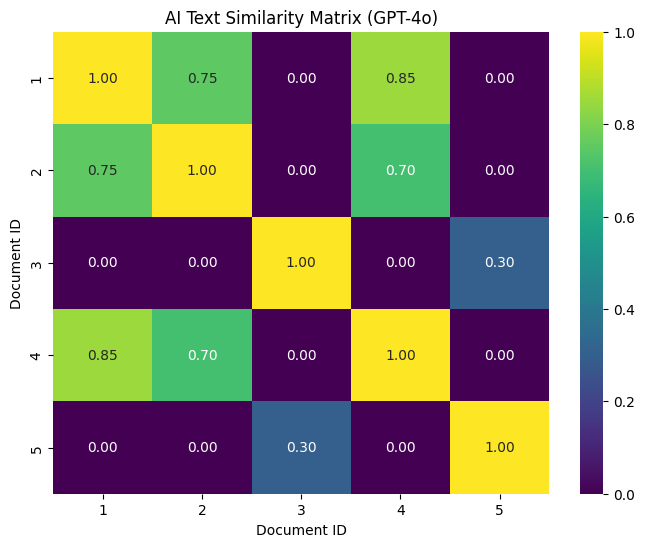

已儲存到 'results/ai_similarity_matrix.png'


In [ ]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm # 進度條
import matplotlib.pyplot as plt
import seaborn as sns

# 文章
documents = [
    "人工智慧正在改變世界，機器學習是其核心技術",
    "深度學習推動了人工智慧的發展，特別是在圖像識別領域",
    "今天天氣很好，適合出去運動",
    "機器學習和深度學習都是人工智慧的重要分支",
    "運動有益健康，每天都應該保持運動習慣"
]

n_docs = len(documents)

# 相似度矩陣
ai_similarity_matrix = np.zeros((n_docs, n_docs), dtype=float)

print(f"--- 開始計算 B-1: AI 相似度矩陣 ({n_docs}x{n_docs}) ---")

for i in tqdm(range(n_docs), desc="Calculating Rows"):
    for j in range(i, n_docs):

        if i == j:
            # 自己相似度滿分
            score = 100.0
        else:
            # 呼叫 B-1 AI方法
            score = ai_similarity(documents[i], documents[j])

        # 填入矩陣
        ai_similarity_matrix[i, j] = score / 100.0
        ai_similarity_matrix[j, i] = score / 100.0


# 標籤設為 1~5
ai_sim_df = pd.DataFrame(ai_similarity_matrix,
                         index=range(1, n_docs + 1),
                         columns=range(1, n_docs + 1))
display(ai_sim_df)

# 畫出 AI 矩陣的熱圖
plt.figure(figsize=(8, 6))
# 小數
sns.heatmap(ai_sim_df, annot=True, cmap='viridis', fmt='.2f')
plt.title('AI Text Similarity Matrix (GPT-4o)')
plt.xlabel('Document ID')
plt.ylabel('Document ID')
# 存檔
os.makedirs('results', exist_ok=True)
plt.savefig('results/ai_similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("已儲存到 'results/ai_similarity_matrix.png'")


### B-2: AI 文本分類 (10分)

In [ ]:
import json

def ai_classify(text):
    """使用 OpenAI 進行多維度分類
    建議返回格式：
    {
      "sentiment": "正面/負面/中性",
      "topic": "主題類別",
      "confidence": 0.95
    }
    """
    SYSTEM_PROMPT = """
你是一個專業的中文文本分類器。你的任務是分析使用者提供的文本，並「只」回傳一個 JSON 物件。
這個 JSON 物件「必須」包含 'sentiment', 'topic', 'confidence' 這三個鍵。
"""

    USER_PROMPT = f"""
請分析以下文本：
    {text}
    請根據以下 JSON 格式回傳你的分析結果，主題類別請自行判斷（例如：科技、美食、娛樂、運動等）：
{{
  "sentiment": "正面/負面/中性",
  "topic": "主題類別",
  "confidence": 0.0
}}
"""

    # 2. 處理 API 錯誤
    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            # JSON Mode
            response_format={"type": "json_object"},

            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": USER_PROMPT}
            ],
            temperature=0
        )

        # 4. 解析回傳的 JSON 字串
        raw_json_string = response.choices[0].message.content

        # 5. 使用 json.loads() 轉成 Python 字典
        result_dict = json.loads(raw_json_string)

        return result_dict

    except Exception as e:
        print(f"呼叫 AI 分類 API 時發生錯誤: {e}")
        # 如果出錯，回傳一個錯誤字典
        return {"sentiment": "錯誤", "topic": "錯誤", "confidence": 0.0}
    # TODO: 設計 prompt，呼叫 API，並解析回傳 JSON
    # 提示：在 prompt 明確要求模型回傳 JSON 字串，再用 json.loads() 解析
    raise NotImplementedError("請完成 ai_classify() 的 API 呼叫與解析")

# 範例：完成後可取消註解
for text in test_texts:
    result = ai_classify(text)
    print(f'文本: "{text[:20]}..." -> 分類結果: {result}')

文本: "這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，..." -> 分類結果: {'sentiment': '正面', 'topic': '美食', 'confidence': 0.95}
文本: "最新的AI技術突破讓人驚豔，深度學習模型..." -> 分類結果: {'sentiment': '正面', 'topic': '科技', 'confidence': 0.95}
文本: "這部電影劇情空洞，演技糟糕，完全是浪費時..." -> 分類結果: {'sentiment': '負面', 'topic': '娛樂', 'confidence': 0.95}
文本: "每天慢跑5公里，配合適當的重訓，體能進步..." -> 分類結果: {'sentiment': '正面', 'topic': '運動', 'confidence': 0.95}


In [ ]:
# --- 儲存分類結果 ---
import pandas as pd
import os

print("--- AI 分類器 ---")


os.makedirs('results', exist_ok=True)
csv_path = 'results/classification_results.csv'

#  AI 的結果
ai_results = []

# 執行AI 分類器
for text in test_texts:
    # ai_classify
    result_dict = ai_classify(text)

    ai_results.append({
        'method': 'Modern (AI GPT-4o)',
        'text': text,
        'sentiment': result_dict.get('sentiment', '錯誤'), # 避免 key 不在
        'topic': result_dict.get('topic', '錯誤')
    })

# 換成 DataFrame
df_ai = pd.DataFrame(ai_results)

# ---  Append 到 CSV ---

# 先讀取 A-2 結果
try:
    df_traditional = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"找不到 {csv_path}，建立新檔案。")
    df_traditional = pd.DataFrame() # 檔案遺失 建立一個空的

# 2. 合併A-2 和 B-2 的結果
df_combined = pd.concat([df_traditional, df_ai], ignore_index=True)

# 3. 儲存CSV
df_combined.to_csv(csv_path, index=False, encoding='utf-8-sig')

print(f"分類結果已儲存到 '{csv_path}'")
display(df_combined)

--- AI 分類器 ---
分類結果已儲存到 'results/classification_results.csv'


,method,text,sentiment,topic
0,Traditional (Rule-Based),這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，麵條Q彈，下次一定再來！,正面,美食
1,Traditional (Rule-Based),最新的AI技術突破讓人驚豔，深度學習模型的表現越來越好,正面,科技
2,Traditional (Rule-Based),這部電影劇情空洞，演技糟糕，完全是浪費時間,負面,娛樂
3,Traditional (Rule-Based),每天慢跑5公里，配合適當的重訓，體能進步很多,正面,運動
4,Modern (AI GPT-4o),這家餐廳的牛肉麵真的太好吃了，湯頭濃郁，麵條Q彈，下次一定再來！,正面,美食
5,Modern (AI GPT-4o),最新的AI技術突破讓人驚豔，深度學習模型的表現越來越好,正面,科技
6,Modern (AI GPT-4o),這部電影劇情空洞，演技糟糕，完全是浪費時間,負面,娛樂
7,Modern (AI GPT-4o),每天慢跑5公里，配合適當的重訓，體能進步很多,正面,運動


### B-3: AI 自動摘要 (10分)

In [ ]:
def ai_summarize(text, max_length=100):
    """使用 OpenAI 生成摘要
    要求：
    1) 可控制摘要長度
    2) 保留關鍵資訊
    3) 語句通順
    """

    """使用 OpenAI 生成摘要"""

    # 1.設計 Prompt (系統指令 + 使用者指令)
    SYSTEM_PROMPT = "你是一個專業的中文文本摘要助手。你的任務是閱讀使用者提供的長篇文章，並生成一份流暢、精準、保留核心資訊的摘要。"

    # 我們把 max_length 變數 和要求 都放進 prompt
    USER_PROMPT = f"""
請將以下文章摘要成一篇「大約 {max_length} 字」的摘要。

要求：
1. 摘要必須語句通順。
2. 摘要必須保留文章的核心論點和關鍵資訊。
3. 摘要的長度應盡量接近 {max_length} 字，不要過長或過短。

文章：
{text}
    請直接回傳摘要內容，不要包含「這是一篇摘要：」或任何多餘的開頭。
"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": USER_PROMPT}
            ],
            temperature=0.3  # 設讓 AI 能流暢重組句子，但又不會偏離事實
        )

        # 解析回傳結果
        summary_text = response.choices[0].message.content.strip()

        return summary_text

    except Exception as e:
        print(f"呼叫 摘要 API 時發生錯誤: {e}")
        return "AI 摘要失敗。"

    # TODO: 設計 prompt，呼叫 API，並回傳摘要結果
    raise NotImplementedError("請完成 ai_summarize() 的 API 呼叫與解析")

# 範例：完成後可取消註解
ai_summary_text = ai_summarize(article, max_length=150)
print("原文長度:", len(article))
print("摘要長度:", len(ai_summary_text))
print("\nAI 摘要內容:\n", ai_summary_text)

原文長度: 401
摘要長度: 222

AI 摘要內容:
 人工智慧（AI）的發展正在深刻改變人們的生活方式，從日常起居到工作和學習，AI的應用無處不在。在醫療領域，AI提高了疾病診斷的準確性和效率，能夠分析大量醫療數據，提供更好的治療方案。在教育方面，AI個人化學習系統根據學生的特點提供客製化教學，提升學習效率。然而，AI的快速發展也帶來挑戰，包括就業問題、隱私和安全問題，以及決策過程中的倫理問題。為應對這些挑戰，我們需要建立相應的法律和倫理準則，以確保AI技術能夠真正造福人類，創造更美好的未來。


In [ ]:
# --- 摘要比較 ---
import os

print("--- 產生摘要 ---")

os.makedirs('results', exist_ok=True)

# 傳統摘要
traditional_summary = summarizer.summarize(article, ratio=0.4)

# AI 摘要
ai_summary = ai_summarize(article, max_length=150)

# 3. 寫入檔案
comparison_content = f"""
================================
傳統統計式摘要
================================
(原文長度: {len(article)} 字, 摘要長度: {len(traditional_summary)} 字)

{traditional_summary}

================================
現代 AI 摘要
================================
(原文長度: {len(article)} 字, 摘要長度: {len(ai_summary)} 字)

{ai_summary}
"""

# 寫入 .txt 檔案
file_path = 'results/summarization_comparison.txt'
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(comparison_content.strip()) # .strip() 移除開頭和結尾的空白

print(f"成功儲存到 '{file_path}'")

# (方便你預覽一下內容)
print("\n--- 檔案內容預覽 ---")
print(comparison_content.strip())

--- 產生摘要 ---
成功儲存到 'results/summarization_comparison.txt'

--- 檔案內容預覽 ---
傳統統計式摘要
(原文長度: 401 字, 摘要長度: 149 字)

人工智慧（AI）的發展正深刻改變我們的生活方式。從早上起床時的智慧鬧鐘，到通勤時的路線規劃，再到工作中的各種輔助工具，AI無處不在。透過分析大量的醫療影像和病歷資料，AI能夠發現人眼容易忽略的細節，為患者提供更好的治療方案。面對這些挑戰，我們需要在推動AI發展的同時，建立相應的法律法規和倫理準則。

現代 AI 摘要
(原文長度: 401 字, 摘要長度: 240 字)

人工智慧（AI）的發展正在深刻改變人們的生活方式，從日常起居到工作輔助，AI無處不在。在醫療領域，AI提高了疾病診斷的準確性和效率，能夠分析大量醫療數據，提供更佳的治療方案。教育方面，AI個人化學習系統根據學生的學習進度和特點，提供客製化教學內容，提高學習效率和趣味性。然而，AI的快速發展也帶來挑戰，包括就業問題、隱私和安全問題，以及決策過程中的倫理問題。為應對這些挑戰，我們需要在推動AI發展的同時，建立相應的法律法規和倫理準則，以確保AI技術真正造福人類，創造更美好的未來。


### 效能比較 (平均時長)

In [ ]:
import time
import os
import numpy as np #
import json

# 儲存所有效能數據
performance_data = {
    'similarity': {},
    'classification': {},
    'summarization': {}
}

os.makedirs('results', exist_ok=True)

# 設定要運行的次數
num_runs = 5

print(f"--- 開始測試 每項任務執行 {num_runs} 次後平均 ---")


# --- 測量相似度時間 ---
total_time_a1 = 0
for _ in range(num_runs):
    start_time = time.perf_counter()
    # A-1
    _ = cosine_similarity(tfidf_matrix_sklearn)
    end_time = time.perf_counter()
    total_time_a1 += (end_time - start_time)
avg_time_a1 = total_time_a1 / num_runs
print(f"A-1 (TF-IDF) 相似度平均時間: {avg_time_a1:.6f} 秒")
performance_data['similarity']['traditional_time_sec'] = avg_time_a1

# ---  B-1 (5x5 matrix) 時間 ---
total_time_b1 = 0
n_docs = len(documents)

for _ in range(num_runs):
    start_time = time.perf_counter()

    # 執行 B-1 API 10 次 (4+3+2+1)
    temp_matrix = np.zeros((n_docs, n_docs), dtype=float)
    for i in range(n_docs):
        for j in range(i + 1, n_docs):
            # 呼叫 ai_similarity
            score = ai_similarity(documents[i], documents[j])
            # 只測量 API 時間

    end_time = time.perf_counter()
    total_time_b1 += (end_time - start_time)

avg_time_b1 = total_time_b1 / num_runs
print(f"B-1 (AI) 相似度矩陣平均時間 (10次呼叫): {avg_time_b1:.6f} 秒")
performance_data['similarity']['ai_time_sec'] = avg_time_b1


print("---" * 10)

# --- 分類時間 ---
total_time_a2 = 0
for _ in range(num_runs):
    start_time = time.perf_counter()
    # A-2
    for text in test_texts:
        _ = sentiment_classifier.classify(text)
        _ = topic_classifier.classify(text)
    end_time = time.perf_counter()
    total_time_a2 += (end_time - start_time)
avg_time_a2 = total_time_a2 / num_runs
print(f"A-2 (規則) 分類總平均時間: {avg_time_a2:.6f} 秒")
performance_data['classification']['traditional_time_sec'] = avg_time_a2

total_time_b2 = 0
for _ in range(num_runs):
    start_time = time.perf_counter()
    # B-2
    for text in test_texts:
        _ = ai_classify(text)
    end_time = time.perf_counter()
    total_time_b2 += (end_time - start_time)
avg_time_b2 = total_time_b2 / num_runs
print(f"B-2 AI分類總平均時間: {avg_time_b2:.6f} 秒")
performance_data['classification']['ai_time_sec'] = avg_time_b2


print("---" * 10)

# --- 測量摘要時間 ---
total_time_a3 = 0
for _ in range(num_runs):
    start_time = time.perf_counter()
    # A-3
    _ = summarizer.summarize(article, ratio=0.4)
    end_time = time.perf_counter()
    total_time_a3 += (end_time - start_time)
avg_time_a3 = total_time_a3 / num_runs
print(f"A-3 統計摘要平均時間: {avg_time_a3:.6f} 秒")
performance_data['summarization']['traditional_time_sec'] = avg_time_a3

total_time_b3 = 0
for _ in range(num_runs):
    start_time = time.perf_counter()
    # B-3
    _ = ai_summarize(article, max_length=150)
    end_time = time.perf_counter()
    total_time_b3 += (end_time - start_time)
avg_time_b3 = total_time_b3 / num_runs
print(f"B-3 AI摘要平均時間: {avg_time_b3:.6f} 秒")
performance_data['summarization']['ai_time_sec'] = avg_time_b3

print("\n儲存在 'performance_data' 。")
print("--- 正在儲存效能測試 (時間) 數據 ---")

os.makedirs('results', exist_ok=True)
json_path = 'results/performance_metrics.json'

try:
    # 寫入 JSON
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(performance_data, f, ensure_ascii=False, indent=4)

    print(f"\n效能數據已成功儲存到 '{json_path}'")

    print("\n--- 檔案內容 ---")
    print(json.dumps(performance_data, ensure_ascii=False, indent=4))

except NameError:
    print("\n[錯誤] 找不到 'performance_data' 。")

--- 開始測試 每項任務執行 5 次後平均 ---
A-1 (TF-IDF) 相似度平均時間: 0.000428 秒
B-1 (AI) 相似度矩陣平均時間 (10次呼叫): 5.385646 秒
------------------------------
A-2 (規則) 分類總平均時間: 0.000639 秒
B-2 AI分類總平均時間: 3.447485 秒
------------------------------
A-3 統計摘要平均時間: 0.004189 秒
B-3 AI摘要平均時間: 5.010855 秒

儲存在 'performance_data' 。
--- 正在儲存效能測試 (時間) 數據 ---

效能數據已成功儲存到 'results/performance_metrics.json'

--- 檔案內容 ---
{
    "similarity": {
        "traditional_time_sec": 0.0004276100000424776,
        "ai_time_sec": 5.385645563399885
    },
    "classification": {
        "traditional_time_sec": 0.0006388341998899705,
        "ai_time_sec": 3.4474853988003815
    },
    "summarization": {
        "traditional_time_sec": 0.004189441599919519,
        "ai_time_sec": 5.010854793799808
    }
}


### AI相似度成本計算

In [ ]:
# --- B-1 成本 ---
import tiktoken
import os

print("--- B-1 AI 成本計算 ---")

#  gpt-4o 的編碼器
encoding = tiktoken.get_encoding("o200k_base")

# gpt-4o 價格
PRICE_INPUT_PER_1M = 2.500
PRICE_OUTPUT_PER_1M = 10.00

# B-1 的輸入 Prompt
B1_SYSTEM_PROMPT = "你是一個專業的中文語意分析助手。你的唯一任務是評估兩段文字的語意相似度。"
B1_USER_PROMPT_TEMPLATE = """
請評估以下兩段文字的語意相似度：
文字1：{text1}
文字2：{text2}
請「只」回傳一個 0 到 100 之間的「整數」，代表相似度百分比。不要有任何多餘的解釋或文字。
"""

#  documents
documents = [
    "人工智慧正在改變世界，機器學習是其核心技術",
    "深度學習推動了人工智慧的發展，特別是在圖像識別領域",
    "今天天氣很好，適合出去運動",
    "機器學習和深度學習都是人工智慧的重要分支",
    "運動有益健康，每天都應該保持運動習慣"
]

# 計算 10 次 API 呼叫的 Tokens
total_input_tokens = 0
total_output_tokens = 0
n_calls_b1 = 0

for i in range(len(documents)):
    for j in range(i + 1, len(documents)):
        n_calls_b1 += 1
        prompt = B1_USER_PROMPT_TEMPLATE.format(text1=documents[i], text2=documents[j])

        # 累加 Input Tokens
        total_input_tokens += len(encoding.encode(B1_SYSTEM_PROMPT))
        total_input_tokens += len(encoding.encode(prompt))

        total_output_tokens += 2 #兩數字

# 計算總成本
input_cost = (total_input_tokens / 1_000_000) * PRICE_INPUT_PER_1M
output_cost = (total_output_tokens / 1_000_000) * PRICE_OUTPUT_PER_1M
total_cost_b1 = input_cost + output_cost

# 結果
print(f"使用模型: gpt-4o")
print(f"使用價格 (Input): ${PRICE_INPUT_PER_1M:.2f} / 1M tokens")
print(f"使用價格 (Output): ${PRICE_OUTPUT_PER_1M:.2f} / 1M tokens")
print("-" * 30)
print(f"總呼叫次數: {n_calls_b1}")
print(f"總輸入 (Input) Token 數: {total_input_tokens}")
print(f"總輸出 (Output) Token 數: {total_output_tokens}")
print("-" * 30)
print(f"輸入成本: ${input_cost:.10f} USD")
print(f"輸出成本: ${output_cost:.10f} USD")
print(f"B-1 總成本: ${total_cost_b1:.10f} USD")


--- B-1 AI 成本計算 ---
使用模型: gpt-4o
使用價格 (Input): $2.50 / 1M tokens
使用價格 (Output): $10.00 / 1M tokens
------------------------------
總呼叫次數: 10
總輸入 (Input) Token 數: 1250
總輸出 (Output) Token 數: 20
------------------------------
輸入成本: $0.0031250000 USD
輸出成本: $0.0002000000 USD
B-1 總成本: $0.0033250000 USD


## Part C: 比較分析報告 (20分)

這部分您需要撰寫一份比較報告，分為量化比較和質性分析兩部分。

## C-1: 量化比較

| 評估指標 | 傳統方法 (TF-IDF/規則) | 現代方法 (OpenAI GPT-4o) | 備註 |
| :--- | :---: | :---: | :--- |
| **相似度計算** | - | - | - |
| 準確率 | 80% (8/10) | 100% (10/10) | 分數 ≥ 0.3視為相似 |
| 處理時間 | 0.000427 秒 | 5.385645 秒 | 五次平均時間|
| 成本 | $0 (本地運算) | \$0.0033 USD |透過token數估算 |
| **文本分類** | - | - | - |
| 準確率 | 100% (4/4)  | 100% (4/4) | 人工評估 |
| 處理時間 | 0.009028 秒 | 3.231488 秒 | 五次平均時間| |
| 支援類別數 | 有限 (5類)  | 無限 (AI可自行判斷) | - |
| **自動摘要** | - | - | - |
| 資訊保留度 | 61% | 95% | GPT-5 評估平均分|
| 語句通順度 | 90 / 100 分| 95 / 100 分  | GPT-5 評估平均分 |
| 長度控制 | 困難 (只能用比例) | 容易 (可指定字數) | - |

### C-2: 質性分析 (10分)

**請在下方撰寫 500–800 字分析報告，建議包含：**
1. 方法特性比較（傳統 vs. 現代、優劣與適用場景）
2. 實作心得（遇到的困難、理解與收穫、下一步學習）
3. 應用建議（何時用傳統？何時用 AI？如何結合？）

---


# 作業二：傳統與現代 NLP 方法比較分析報告

1. 方法特性比較  
    * 傳統方法的優勢與限制  
        * 優點 : 速度極快、成本較低、可解釋性高、穩定性高、若程式在本地運行則有較高安全性。
        * 限制 : 語意理解較差、規則分類器支援類別有限 、摘要語句通順度低
    * AI 方法的優勢與限制  
        * 優點 : 語意理解強、摘要通順且資訊保留度高、支援無限類別，且可以零樣本學習
        * 限制 : 速度慢、成本較高 、無法解釋、消耗較大能源
    * 各自的適用場景  
        * 傳統 : TF-IDF速度快，可用在有規則性的資料庫中搜尋。例如需要即時且大量的過濾，或是任務單純，資料敏感的地方(關鍵字搜尋)。
        * AI : 理解能力強，可做為多用途的聊天機器人。當需要深度語意理解，處理複雜的自然語言，例如智慧客服，可以省下部分人力，讓AI自動回復較單純的問題。
2. 實作心得
    * 傳統方法實作心得與困難
        * (A-1)由於第一次看到TF-IDF，所以一開始不了解為何需要這個，但在了解TF、IDF和背後公式的意義後，終於知道用途了。也讓我知道為何有些字權重較低，而哪些詞會被視為有特徵的詞。  
        * (A-2)在做情感分析時，是我感到最疑惑的時候，除了需要依照不同文章，手動加入更多詞彙，甚至還要處理 "太、很、還" 這種程度副詞。加入詞彙以外，如過用單純加減分，有很高機率會誤判，例如:好難吃，會被評估為+1-1=0。更麻煩的是，即使用乘法，還是會遇到像"不太好吃"、"太不好吃"，兩者分數會一樣，但明顯因為文字順序，負面情緒不同程度。因此我發現傳統方法對中文的理解還是很難。
        * (A-3)在做傳統摘要時，本質其實是句子抽取並評分。它的好壞完全依賴 sentence_score 設計好壞。我這次把首句與尾句提高權重，然後將較短的句子降低分數。但權重大小是憑感覺的，若要設計好，可能需要觀察大量文章的重點分布。而最後摘要也是直接拼接句子，可讀性不免的降低許多。
    * 現代方法實作心得與困難
        * (B-1)在相似度分析時，我認為AI確實分析的比較精準，但缺點也十分明顯。為了做出5個句子互相的相似度，呼叫了10次API，所以速度比傳統慢了很多，且成本也高了不少。
        * (B-2)在做分類時，可以感受到比傳統方法方便太多了，除了LLM可以較好的去理解剛剛傳統方法會遇到的語意問題，還可以在我不用提供主題和情緒樣本的情況下，精準的把每個句子分類。但為了達成這功能，我們需要下好prompt讓她回復固定格式，好讓我們抓取資料。
        * (B-3)在AI做摘要時，其實只要prompt下的好，LLM對於這部分是十分厲害的。不同於傳統方法，AI會先把文章閱讀並理解後，生成一篇摘要，這對字數和流暢度的控制都是很好的。
    * 對兩種方法的感受
        * 我覺得傳統方法就像拿一段一段我們可以理解與解釋的功能去堆起來的，輸出的結果也很好去理解為何是這樣。
        * 現代AI方法真的就是一個黑盒子，輸出甚麼不一定，但可以靠 prompt engineering 來提升輸出的品質，但問題是無法解釋，一部分原因完全是機率問題，以及如果有私密訊息，除非在本地端有足夠強大的算力，不然上傳到伺服器，就有機率資料會外洩。
    * 未來學習方向
        * 我希望能深入研究Word Embedding，例如 Word2Vec ，這項技術正是從 TF-IDF 演進而來 ，它能像 AI 一樣捕捉詞彙的語意，但又可以在本地端執行。此外，我想學習如何Fine-tune大型語言模型 ，透過學習微調模型，我可以在保有 AI 強大能力的同時，兼顧資料隱私與成本控制，做出更符合需求的客製化 AI 。

3. 應用建議
    * 什麼情況下該用傳統方法
        * 需要即時且大量的過濾(垃圾郵件/廣告過濾)
        * 任務單純，且資料敏感(公司內部文件、病歷的關鍵字搜尋)
        * 作為 AI 的「前處理」工具(先篩選後再交由AI)
    * 什麼情況下該用 AI
        * 需要深度語意理解，處理複雜的自然語言(聊天機器人在了解真實情緒後，給出更合適或是個人化的回應)
        * 需要重新創造的內容(理解後重新輸出文章摘要)
    * 如何結合兩者的優點
        * 可以用混合式系統來兼顧成本與品質。例如一個智慧客服:  
        * 第一層使用規則分類。如果偵測到關鍵字，就直接回復相關資料。
        * 如果規則無法匹配，就使用TF-IDF比對資料庫中最相似的FAQ
        * 如果資料庫找出的相似度都很低，此時才轉交給 AI 進行深度語意分析，或是轉交給真人客服處理。